In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def log_likelihood(vr, mu, sig, e_vr=0):
    total_var = sig**2 + e_vr**2
    single_logp = -0.5 * (np.log(2 * np.pi * total_var) + (vr - mu) ** 2 / total_var)
    return np.sum(single_logp)

In [3]:
def metropolis(vr_data, e_vr=0, n_samples=10000, mu_init=0, sig_init=1,clip=2000):
    count_accepted=0
    chain = np.zeros((n_samples, 3))
    logL0 = log_likelihood(vr_data, mu_init, sig_init, e_vr)
    chain[0] = [mu_init, sig_init, logL0]

    for i in range(1, n_samples):
        mu_current, sig_current, logL_current = chain[i-1]
        mu_proposal = np.random.normal(mu_current, 5)
        sig_proposal = np.random.normal(sig_current, 5)
        if sig_proposal <= 0:
            chain[i] = [mu_current, sig_current, logL_current]
            continue
        
        logL_prop = log_likelihood(vr_data, mu_proposal, sig_proposal, e_vr)
        accept_alpha = min(1, np.exp(logL_prop - logL_current))

        a = np.random.rand()
        if a < accept_alpha:
            count_accepted+=1
            chain[i] = [mu_proposal, sig_proposal, logL_prop]
        else:
            chain[i] = [mu_current, sig_current, logL_current]

    return chain[clip:]

In [4]:
def get_quantile_interval(chain):
    mu16, mu50, mu84 = np.percentile(chain, [16, 50, 84])
    mu_err_low = mu50 - mu16
    mu_err_high = mu84 - mu50
    return mu50,mu16,mu84, mu_err_low, mu_err_high

In [5]:
def mcmc_chain_to_1d_likelihood(param_chain, bins=100):
    counts, bin_edges = np.histogram(param_chain, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    L1d = counts
    return L1d, bin_centers

def get_likelihood_interval(L1d, param_grid):
    lnL1d = np.log(L1d)
    lnL_max = np.max(lnL1d)
    threshold = lnL_max - 0.5
    peak_idx = np.argmax(lnL1d)
    peak_val = param_grid[peak_idx]
    mask_left = param_grid <= peak_val
    mask_right = param_grid >= peak_val
    x_left = lnL1d[mask_left]
    y_left = param_grid[mask_left]
    left_bound = np.interp(threshold, x_left, y_left)
    x_right = np.flip(lnL1d[mask_right])
    y_right = np.flip(param_grid[mask_right])
    right_bound = np.interp(threshold, x_right, y_right)

    err_low = peak_val - left_bound
    err_high = right_bound - peak_val
    return peak_val, left_bound, right_bound, err_low, err_high

In [6]:
def plot_mcmc_1d(
    param_chain, bin_centers, L1d_counts,
    q16, q50, q84, peak, left, right,
    xlabel
):
    fig,ax = plt.subplots(figsize=(5,3))
    ax.hist(param_chain, bins=len(bin_centers), alpha=0.35, color="steelblue", label="MCMC Sample Histogram")
    ax.plot(bin_centers, L1d_counts, color="black", lw=1.3, label="Marginalized Count Likelihood")
    ax.axvline(q50, color="red", linestyle="--", label="Median (50% quantile)")
    ax.axvspan(q16, q84, alpha=0.22, color="orange", label="68% Quantile Interval")
    ax.axvline(peak, color="limegreen", linestyle="-.", label="Likelihood Peak")
    ax.axvspan(left, right, alpha=0.22, color="royalblue", label=r"$\Delta \ln\mathcal{L}=-0.5$ Interval")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of MCMC samples")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

C:\Users\32166\AppData\Local\Temp\ipykernel_31720\2644578357.py:16: RuntimeWarning: overflow encountered in exp
  accept_alpha = min(1, np.exp(logL_prop - logL_current))


平均视向速度
分位数法：中位数=-371.54, -0.63, +0.64
似然阈值法：峰值=-371.70, -0.37, +0.80

速度弥散
分位数法：中位数=8.36, -0.47, +0.56
似然阈值法：峰值=8.17, -0.27, +0.61


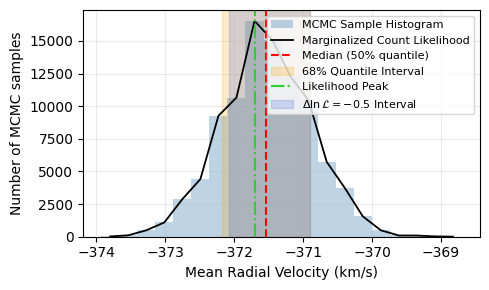

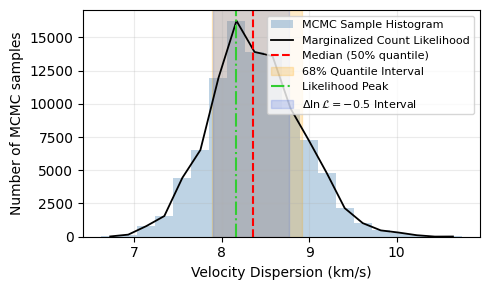

In [7]:
df=pd.read_csv('data/cas3.csv')
vr_data = df["vr"].values
e_vr=df["e_vr"].values

chain_clipped = metropolis(vr_data, e_vr, n_samples=100000, mu_init=-350, sig_init=1,clip=5000)
mu_chain = chain_clipped[:, 0]
sig_chain = chain_clipped[:, 1]
lnL_chain = chain_clipped[:, 2]


mu_med,m16,m84, mu_err_low, mu_err_high = get_quantile_interval(mu_chain)
sig_med, sig16, sig84, sig_err_low, sig_err_high = get_quantile_interval(sig_chain)

L1d_mu, mu_bin_grid = mcmc_chain_to_1d_likelihood(mu_chain, bins=20)
L1d_sig, sig_bin_grid = mcmc_chain_to_1d_likelihood(sig_chain, bins=20)
mu_peak, mu_left, mu_right, mu_err_low_li, mu_err_high_li = get_likelihood_interval(L1d_mu, mu_bin_grid)
sig_peak, sig_left, sig_right, sig_err_low_li, sig_err_high_li = get_likelihood_interval(L1d_sig, sig_bin_grid)

print("平均视向速度")
print(f"分位数法：中位数={mu_med:.2f}, -{mu_err_low:.2f}, +{mu_err_high:.2f}")
print(f"似然阈值法：峰值={mu_peak:.2f}, -{mu_err_low_li:.2f}, +{mu_err_high_li:.2f}")
print("\n速度弥散")
print(f"分位数法：中位数={sig_med:.2f}, -{sig_err_low:.2f}, +{sig_err_high:.2f}")
print(f"似然阈值法：峰值={sig_peak:.2f}, -{sig_err_low_li:.2f}, +{sig_err_high_li:.2f}")
plot_mcmc_1d(
    mu_chain, mu_bin_grid, L1d_mu,
    m16, mu_med, m84, mu_peak, mu_left, mu_right,
    xlabel="Mean Radial Velocity (km/s)")
plot_mcmc_1d(
    sig_chain, sig_bin_grid, L1d_sig,
    sig16, sig_med, sig84, sig_peak, sig_left, sig_right,
    xlabel="Velocity Dispersion (km/s)")